<a href="https://colab.research.google.com/github/naveen-ramavath/Deep-Learning/blob/main/dl_internal_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# pre-trained models LeNet, AlexNet, ZF-Net, VGGNet, Google Inception Module, Resnet.

In [ ]:
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

model = Sequential([
    Conv2D(6,(5,5),activation='tanh',input_shape=(28,28,1)),
    AveragePooling2D((2,2)),
    Conv2D(16,(5,5),activation='tanh'),
    AveragePooling2D((2,2)),
    Flatten(),
    Dense(120,activation='tanh'),
    Dense(84,activation='tanh'),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=3,batch_size=128)
print(model.evaluate(x_test,y_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8982 - loss: 0.3480
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9607 - loss: 0.1291
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9745 - loss: 0.0843
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9770 - loss: 0.0742
[0.07415468245744705, 0.9769999980926514]


## alexnet

In [1]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# normalize + reshape
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

# one-hot encoding
y_train = keras.utils.to_categorical(y_train,10)
y_test  = keras.utils.to_categorical(y_test,10)

# model (AlexNet-style)
model = Sequential([

    # Conv Block 1
    Conv2D(64,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    # Conv Block 2
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    # Conv Block 3
    Conv2D(256,(3,3),activation='relu'),

    # Fully connected
    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(10,activation='softmax')
])

# compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# train
model.fit(x_train, y_train, epochs=5, batch_size=128)

# test
print(model.evaluate(x_test, y_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.9050 - loss: 0.3059
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9801 - loss: 0.0762
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9857 - loss: 0.0535
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9896 - loss: 0.0398
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9917 - loss: 0.0316
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9921 - loss: 0.0261
[0.026079092174768448, 0.9921000003814697]


## zfnet

In [6]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# normalize + reshape
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

# one-hot encoding
y_train = keras.utils.to_categorical(y_train,10)
y_test  = keras.utils.to_categorical(y_test,10)

# ZFNet-style model adjusted for MNIST
model = Sequential([

    # Conv 1 (smaller kernel and strides for 28x28 input)
    Conv2D(96,(3,3),strides=1,activation='relu',input_shape=(28,28,1), padding='same'),
    MaxPooling2D((2,2)), # Output: 14x14

    # Conv 2
    Conv2D(256,(3,3),activation='relu', padding='same'),
    MaxPooling2D((2,2)), # Output: 7x7

    # Conv 3
    Conv2D(384,(3,3),activation='relu', padding='same'),

    # Conv 4
    Conv2D(384,(3,3),activation='relu', padding='same'),

    # Conv 5
    Conv2D(256,(3,3),activation='relu', padding='same'),

    Flatten(),
    Dense(256,activation='relu'),
    Dense(10,activation='softmax')
])

# compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# train
model.fit(x_train, y_train, epochs=5, batch_size=128)

# test
print(model.evaluate(x_test, y_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 49ms/step - accuracy: 0.9457 - loss: 0.1754
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9874 - loss: 0.0406
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9906 - loss: 0.0301
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9930 - loss: 0.0228
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9937 - loss: 0.0200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9931 - loss: 0.0220
[0.02195984125137329, 0.9930999875068665]


## vggnet

In [ ]:
import keras, tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense
from tensorflow.keras.applications import VGG16

# data
(x_train,y_train),(x_test,y_test) = mnist.load_data()
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

# resize + RGB
x_train = tf.image.resize(x_train,(32,32))
x_test  = tf.image.resize(x_test,(32,32))
x_train = tf.repeat(x_train,3,axis=-1)
x_test  = tf.repeat(x_test,3,axis=-1)

y_train = keras.utils.to_categorical(y_train,10)
y_test  = keras.utils.to_categorical(y_test,10)

# model
base = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

model = Sequential([
    base,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile('adam','categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=3)
print(model.evaluate(x_test,y_test))

Epoch 1/3
1585/1875 ━━━━━━━━━━━━━━━━━━━━ 16:25 3s/step - accuracy: 0.6446 - loss: 0.9783

## googlennet

In [ ]:
import keras, tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense
from tensorflow.keras.applications import InceptionV3

# data
(x_train,y_train),(x_test,y_test) = mnist.load_data()
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

# resize + RGB
x_train = tf.image.resize(x_train,(75,75))
x_test  = tf.image.resize(x_test,(75,75))
x_train = tf.repeat(x_train,3,axis=-1)
x_test  = tf.repeat(x_test,3,axis=-1)

y_train = keras.utils.to_categorical(y_train,10)
y_test  = keras.utils.to_categorical(y_test,10)

# model
base = InceptionV3(weights='imagenet', include_top=False, input_shape=(75,75,3))

model = Sequential([
    base,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile('adam','categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=3)
print(model.evaluate(x_test,y_test))

## resnnet

In [ ]:
import keras, tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense
from tensorflow.keras.applications import ResNet50

# data
(x_train,y_train),(x_test,y_test) = mnist.load_data()
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

# resize + RGB
x_train = tf.image.resize(x_train,(32,32))
x_test  = tf.image.resize(x_test,(32,32))
x_train = tf.repeat(x_train,3,axis=-1)
x_test  = tf.repeat(x_test,3,axis=-1)

y_train = keras.utils.to_categorical(y_train,10)
y_test  = keras.utils.to_categorical(y_test,10)

# model
base = ResNet50(weights='imagenet', include_top=False, input_shape=(32,32,3))

model = Sequential([
    base,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile('adam','categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=3)
print(model.evaluate(x_test,y_test))

# visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


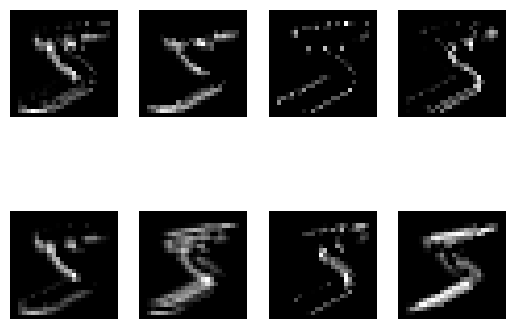

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Conv2D, MaxPooling2D, Input
import matplotlib.pyplot as plt

# load data
(x_train, _), _ = datasets.mnist.load_data()
x_train = x_train/255.0
x_train = x_train.reshape(-1,28,28,1)

# define model using Functional API
input_layer = Input(shape=(28,28,1))
x = Conv2D(8,(3,3),activation='relu')(input_layer)
x = MaxPooling2D((2,2))(x)
x = Conv2D(16,(3,3),activation='relu')(x)

model = Model(inputs=input_layer, outputs=x)

# now extract feature maps from the first Conv2D layer
layer_model = Model(inputs=model.input, outputs=model.layers[1].output)

# pick image
img = x_train[0].reshape(1,28,28,1)

# get feature maps
feature_maps = layer_model.predict(img)

# plot
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.show()


# Guided Backpropagation

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3682


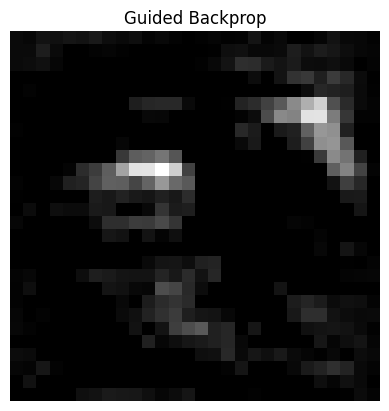

In [ ]:
import tensorflow as tf
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense
import matplotlib.pyplot as plt

# load data
(x_train, y_train), _ = datasets.mnist.load_data()
x_train = x_train/255.0
x_train = x_train.reshape(-1,28,28,1)

# simple model
model = Sequential([
    keras.layers.Input(shape=(28,28,1)),
    Conv2D(8,(3,3),activation='relu'),
    Flatten(),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.fit(x_train, y_train, epochs=1, batch_size=128)

# pick one image
img = tf.convert_to_tensor(x_train[0:1])

# guided backprop
with tf.GradientTape() as tape:
    tape.watch(img)
    preds = model(img)
    loss = preds[:, tf.argmax(preds[0])]

grads = tape.gradient(loss, img)

# keep only positive gradients
guided_grads = tf.maximum(grads, 0)

# show result
plt.imshow(guided_grads[0,:,:,0], cmap='gray')
plt.title("Guided Backprop")
plt.axis('off')
plt.show()

# Implement Auto Encoder model on MINIST dataset.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2469
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1433
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1176
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1036
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0949
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


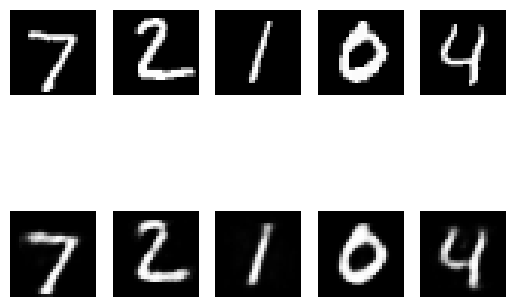

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense, Flatten, Reshape
import matplotlib.pyplot as plt

# load data
(x_train, _), (x_test, _) = datasets.mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

# flatten images
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

# encoder
input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)

# decoder
decoded = Dense(784, activation='sigmoid')(encoded)

# model
autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# train
autoencoder.fit(x_train, x_train, epochs=5, batch_size=256)

# test
decoded_imgs = autoencoder.predict(x_test[:5])

# show original vs reconstructed
for i in range(5):
    # original
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# undercomplete overcomplte

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2414
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1436
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1181
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


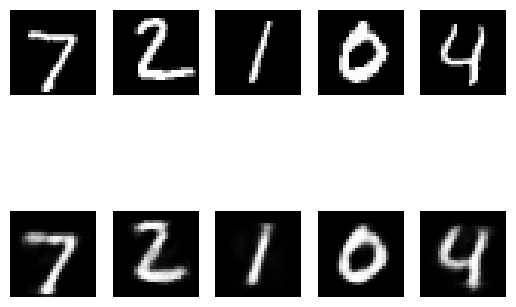

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense
import matplotlib.pyplot as plt

# load data
(x_train, _), (x_test, _) = datasets.mnist.load_data()
x_train = x_train/255.0
x_test = x_test/255.0

x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

# model
input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

model = Model(input_img, decoded)
model.compile(optimizer='adam', loss='binary_crossentropy')

model.fit(x_train, x_train, epochs=3, batch_size=256)

# predict
decoded_imgs = model.predict(x_test[:5])

# show images
for i in range(5):
    # original
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1362
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0748
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0689
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


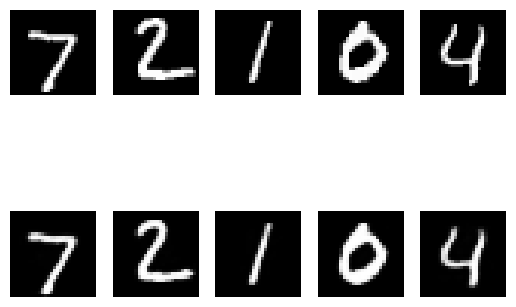

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense
import matplotlib.pyplot as plt

# load data
(x_train, _), (x_test, _) = datasets.mnist.load_data()
x_train = x_train/255.0
x_test = x_test/255.0

x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

# model
input_img = Input(shape=(784,))
encoded = Dense(1024, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

model = Model(input_img, decoded)
model.compile(optimizer='adam', loss='binary_crossentropy')

model.fit(x_train, x_train, epochs=3, batch_size=256)

# predict
decoded_imgs = model.predict(x_test[:5])

# show images
for i in range(5):
    # original
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# regularized ae

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4034
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2639
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2405
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step


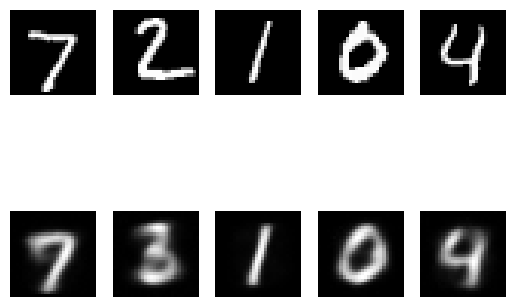

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense, Dropout
from keras import regularizers
import matplotlib.pyplot as plt

# load data
(x_train, _), (x_test, _) = datasets.mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

# model
input_img = Input(shape=(784,))

# ✅ regularization added here
encoded = Dense(128, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_img)

encoded = Dropout(0.3)(encoded)

decoded = Dense(784, activation='sigmoid')(encoded)

model = Model(input_img, decoded)

model.compile(optimizer='adam', loss='binary_crossentropy')

model.fit(x_train, x_train, epochs=3, batch_size=256)

# predict
decoded_imgs = model.predict(x_test[:5])

# show images
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# denoising ae

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2575
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1707
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1506


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


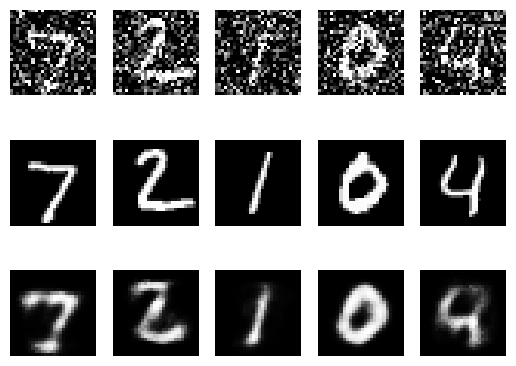

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense
import numpy as np
import matplotlib.pyplot as plt

# load data
(x_train, _), (x_test, _) = datasets.mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

# 🔥 add noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# keep values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# model
input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

model = Model(input_img, decoded)
model.compile(optimizer='adam', loss='binary_crossentropy')

# 🔥 train (noisy → clean)
model.fit(x_train_noisy, x_train, epochs=3, batch_size=256)

# predict
decoded_imgs = model.predict(x_test_noisy[:5])

# show results
for i in range(5):
    # noisy input
    plt.subplot(3,5,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # clean original
    plt.subplot(3,5,i+6)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # reconstructed
    plt.subplot(3,5,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# pca and ae

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step


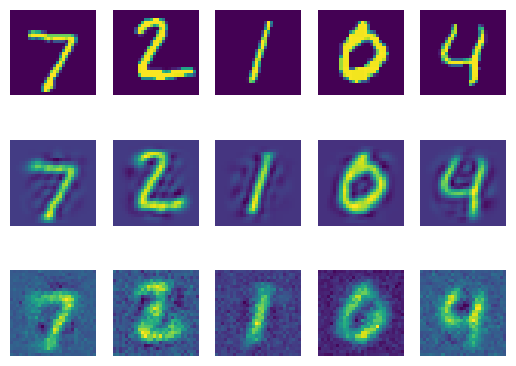

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from keras.datasets import mnist
from keras.layers import Input, Dense
from keras.models import Model

# data
(x_train,_),(x_test,_) = mnist.load_data()
x_test = x_test.reshape(-1,784)/255

# 🔹 PCA
pca = PCA(64)
x_pca = pca.fit_transform(x_test)
x_pca_recon = pca.inverse_transform(x_pca)

# 🔹 Autoencoder
inp = Input(shape=(784,))
x = Dense(64, activation='linear')(inp)   # important
out = Dense(784, activation='linear')(x)
ae = Model(inp,out)

ae.compile('adam','mse')
ae.fit(x_test,x_test,epochs=2,batch_size=256,verbose=0)

x_ae = ae.predict(x_test[:5])

# show results
for i in range(5):
    plt.subplot(3,5,i+1); plt.imshow(x_test[i].reshape(28,28)); plt.axis('off')
    plt.subplot(3,5,i+6); plt.imshow(x_pca_recon[i].reshape(28,28)); plt.axis('off')
    plt.subplot(3,5,i+11); plt.imshow(x_ae[i].reshape(28,28)); plt.axis('off')

plt.show()

# Implement Sparse AE and Contractive AE.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.3927
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 0.2385
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.2136
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1997
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1904
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


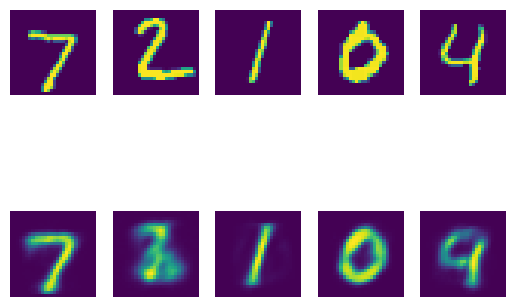

In [ ]:
import keras, matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.layers import Input, Dense
from keras.models import Model
from keras import regularizers

# data
(x_train,_),(x_test,_) = mnist.load_data()
x_train = x_train.reshape(-1,784)/255
x_test = x_test.reshape(-1,784)/255

# model
inp = Input(shape=(784,))
x = Dense(128, activation='relu',
          activity_regularizer=regularizers.l1(1e-5))(inp)
out = Dense(784, activation='sigmoid')(x)
model = Model(inp,out)

model.compile('adam','binary_crossentropy')
model.fit(x_train,x_train,epochs=5,batch_size=256)

# predict
res = model.predict(x_test[:5])

# show
for i in range(5):
    plt.subplot(2,5,i+1); plt.imshow(x_test[i].reshape(28,28)); plt.axis('off')
    plt.subplot(2,5,i+6); plt.imshow(res[i].reshape(28,28)); plt.axis('off')
plt.show()

Epoch 1/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0593
Epoch 2/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0260
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


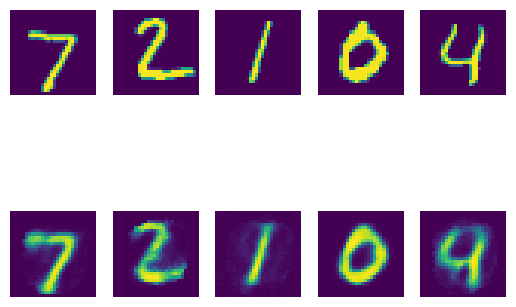

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.layers import Input, Dense
from keras.models import Model

(x_train,_),(x_test,_) = mnist.load_data()
x_train = x_train.reshape(-1,784)/255
x_test = x_test.reshape(-1,784)/255

inp = Input(shape=(784,))
x = Dense(64, activation='relu')(inp)
out = Dense(784, activation='sigmoid')(x)
model = Model(inp,out)

def loss_fn(y_true,y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

model.compile('adam', loss_fn)
model.fit(x_train,x_train,epochs=2,batch_size=256)

res = model.predict(x_test[:5])

for i in range(5):
    plt.subplot(2,5,i+1); plt.imshow(x_test[i].reshape(28,28)); plt.axis('off')
    plt.subplot(2,5,i+6); plt.imshow(res[i].reshape(28,28)); plt.axis('off')
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0667
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0344
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0273
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0227
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0195
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
(5, 784)


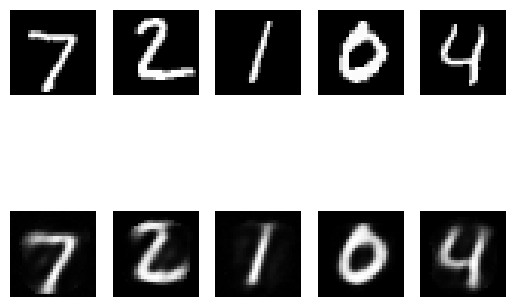

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
# data
(x_train,_),(x_test,_) = mnist.load_data()
x_train = x_train.reshape(-1,784)/255.0
x_test  = x_test.reshape(-1,784)/255.0

# model
inp = Input(shape=(784,))
hidden = Dense(64, activation='relu')(inp)
out = Dense(784, activation='sigmoid')(hidden)
model = Model(inp, out)

lambda_c = 1e-4

# simplified contractive loss
def loss_fn(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    W = model.layers[1].kernel   # hidden layer weights
    contractive = tf.reduce_sum(tf.square(W))

    return mse + lambda_c * contractive

model.compile(optimizer='adam', loss=loss_fn)

# train
model.fit(x_train, x_train, epochs=5, batch_size=256)

# test
res = model.predict(x_test[:5])
print(res.shape)

#visualization

for i in range(5):
    # original image
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # reconstructed image
    plt.subplot(2,5,i+6)
    plt.imshow(res[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# RNN

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.utils import to_categorical

# sample text
text = "hello world"

# unique chars
chars = sorted(list(set(text)))
char_to_int = {c:i for i,c in enumerate(chars)}
int_to_char = {i:c for c,i in char_to_int.items()}

# prepare data
X, y = [], []
for i in range(len(text)-3):
    seq = text[i:i+3]
    label = text[i+3]
    X.append([char_to_int[c] for c in seq])
    y.append(char_to_int[label])

X = to_categorical(X, num_classes=len(chars))
y = to_categorical(y, num_classes=len(chars))

# model
model = Sequential([
    SimpleRNN(32, input_shape=(3,len(chars))),
    Dense(len(chars), activation='softmax')
])

model.compile('adam','categorical_crossentropy')
model.fit(X,y,epochs=200,verbose=0)

# test
test = "hel"
x = to_categorical([[char_to_int[c] for c in test]], num_classes=len(chars))
pred = model.predict(x)

print("Next char:", int_to_char[np.argmax(pred)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Next char: l


# BERT

In [ ]:
# !pip install -q transformers

from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

text = "I hate this product!"

result = classifier(text)[0]

binary_output = 1 if result['label'] == "POSITIVE" else 0

print("Text:", text)
print("Model Output:", result)
print("Binary:", binary_output)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Text: I hate this product!
Model Output: {'label': 'NEGATIVE', 'score': 0.9997503161430359}
Binary: 0


# GAN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
(1, 784)


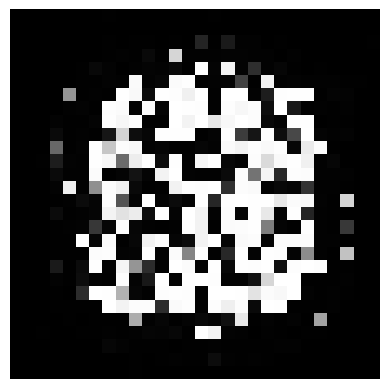

In [ ]:
import tensorflow as tf
import numpy as np

# data
(x_train,_),_ = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1,784)/255.0

# generator
generator = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=100),
    tf.keras.layers.Dense(784, activation='sigmoid')
])

# discriminator
discriminator = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=784),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

discriminator.compile('adam','binary_crossentropy')

# GAN
discriminator.trainable = False
z = tf.keras.Input(shape=(100,))
gan = tf.keras.Model(z, discriminator(generator(z)))
gan.compile('adam','binary_crossentropy')

# training (minimal)
for _ in range(500):
    idx = np.random.randint(0, x_train.shape[0], 32)
    real = x_train[idx]

    noise = np.random.normal(0,1,(32,100))
    fake = generator.predict(noise, verbose=0)

    discriminator.trainable = True
    discriminator.train_on_batch(real, np.ones((32,1)))
    discriminator.train_on_batch(fake, np.zeros((32,1)))

    discriminator.trainable = False
    gan.train_on_batch(noise, np.ones((32,1)))

# generate sample
img = generator.predict(np.random.normal(0,1,(1,100)))
print(img.shape)

import matplotlib.pyplot as plt

plt.imshow(img.reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()